# CREDIT LOAN RISK DATA ANALYSIS

Credits to Lao Tse for the dataset.
You can access the dataset [here](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)

### Data Analysis and Exploration

In this part of the notebook, the cleaned data are examined and analyzed for to answer the questions stated on the previous notebook. The hypothesis of the questions are formed based on the exploration of data conducted in this notebook. With hypothesis, the following questions are:

* What is the overall default rate in our dataset?
  * *Ho*: The default rate is greater than 20%.
  * *Ha*: The default rate is less than 20%.
* How does the DTI (Debt to Income) ratio correlate with the likelihood of defaulted loans? 
  * *Ho*: There is no relationship between the DTI and the likelihood of defaulting. 
  * *Ha*: There is a relationship between the DTI and the likelihood of defaulting. 
* What would an average borrower profile look like?
* What is the average loan amount requested per age group?
  * *Ho*: The average income for each age group does not vary.
  * *Ha*: 18 to 25 average around $20,000, 26 to 45 average around $50,000, 46 to 55 average around $70,000, 56 to 65 average around $100,000, while 66 and above average around $120,000
* Do borrowers with longer credit history borrow more money?
  *  *Ho*: The credit history does not affect the amount of money loaned.
  *  *Ha*: The credit history affects the amount of money loaned.


#### Data Analysis of Each Columns

##### Age

Examining the age of the borrowers can help in analyzing the credit risk of borrowers and how it affects the loan and its attributes. The analyst used the following code to proceed:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [4]:
person_ages = pd.read_csv('cleaned_data/cleaned_person_ages.csv')
person_ages.info()
person_ages.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Clean_person_age  32581 non-null  int64
dtypes: int64(1)
memory usage: 254.7 KB


,Clean_person_age
count,32581.000000
mean,27.719254
std,6.206590
min,20.000000
25%,23.000000
50%,26.000000
75%,30.000000
max,94.000000


The code shows the statistical summary of the cleaned data. Grouping the ages into subsets can provide more insights such as how much of the age groups occupy most of the data. This can be done using the following:

In [5]:
age_young_group = person_ages[(person_ages >= 18) & (person_ages <= 25)] # Get all ages between 18 and 25
age_middle_group = person_ages[(person_ages >= 26) & (person_ages <= 40)] # Get all ages between 26 and 40
age_old_group = person_ages[(person_ages >= 41) & (person_ages <= 55)] # Get all ages between 41 and 55
age_pre_retire_group = person_ages[(person_ages >= 56) & (person_ages <= 65)] # Get all ages between 56 and 65
age_retire_group = person_ages[person_ages >= 66] # Get all ages 66 and above

# Store the count of each subgroup into a dataframe
age_groups = pd.DataFrame([
  age_young_group.count(), 
  age_middle_group.count(),
  age_old_group.count(),
  age_pre_retire_group.count(),
  age_retire_group.count()
  ], index=['18-25','26-40','41-55','56-65','66+']
)
age_groups = age_groups.rename_axis('Age Group')
age_groups = age_groups.rename(columns={'Clean_person_age':'Count'}) # Change column name
age_groups


,Count
Age Group,
18-25,15354
26-40,15735
41-55,1358
56-65,104
66+,30


Text(0.5, 1.0, 'Age Groups and Number of borrowers.')

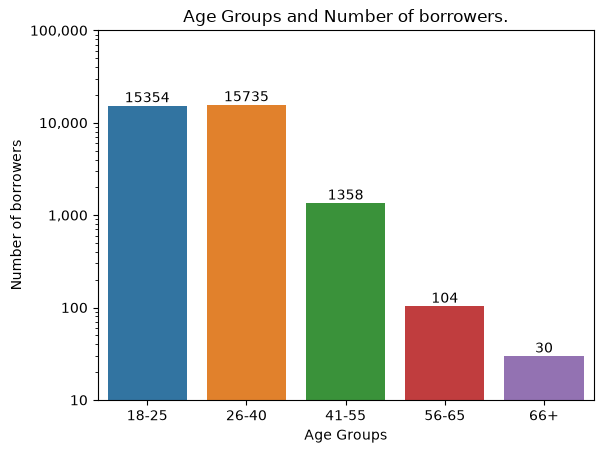

In [6]:
chart = sb.barplot(age_groups, x='Age Group', y='Count', hue='Age Group', legend=False) # Plot the data with x as the age groups and y as the count
for x in chart.containers:
  chart.bar_label(x)

chart.set_yscale('log', base=10) # Scale the y-axis as log base of 10
chart.set_yticks([10, 100, 1000, 10000,100000])  # Display these specific ticks
chart.set_yticklabels(['10', '100', '1,000', '10,000','100,000']) # Set the labels
chart.yaxis.set_minor_formatter(plt.NullFormatter()) # Show only the needed tick labels

chart.set_xlabel('Age Groups') # x label
chart.set_ylabel('Number of borrowers') # y label
chart.set_title('Age Groups and Number of borrowers.') # title

The results show the number of borrowers divided into separate subgroups. The group of `26-40` ranks the most with the highest number of borrowers followed by `18-25`, then `41-55`, then `56-65` then finally, `66+`. Compared to `18-25` and `26-40`, the gap between them ranges immensely, from `15,354` to `1,358`, `1034`, and `38`. This shows that majority of the borrowers have the ages `18-40`. Basically diving the ages into two groups. To demonstrate the differences, the following pie chart will show the difference:

Text(0.5, 1.0, 'Two Groups of Borrowers By Ages')

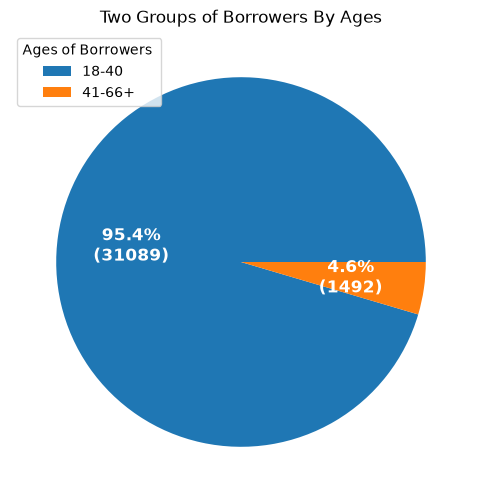

In [7]:
first_group = age_young_group.count() + age_middle_group.count() # Get first group
second_group = age_old_group.count() + age_pre_retire_group.count() + age_retire_group.count() # Get second group
groups = pd.DataFrame([first_group, second_group]) # store as dataframe

fig, ax = plt.subplots(figsize=(6,6)) # Create one subplot
pie = ax.pie(groups['Clean_person_age']) # Make piechart of the column

# Set pie chart labels
ax.pie_label(pie, '{frac:.1%}\n({absval:d})', 
              textprops=dict(color='w', size=12, weight='bold')
              )

# Set pie chart legends
ax.legend(pie.wedges,['18-40','41-66+'],
            title='Ages of Borrowers '
           )

# Set pie chart title
ax.set_title('Two Groups of Borrowers By Ages')

To conclude, `95.4%` of the dataset consists of borrowers aged 18-44, with the remaining `4.6%` aged 45 or above. The average borrower profile can therefore be concluded to fall within the 18-44 age range.

##### Income

Income is very important as it is the main way a loan can be paid. For loaners, this is the basis on how long a loan will last and the basis for the DTI. The data can be examined further using the following:

In [8]:
person_incomes = pd.read_csv('cleaned_data/cleaned_person_incomes.csv')
person_incomes.info()
person_incomes.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Clean_person_income  32581 non-null  int64
dtypes: int64(1)
memory usage: 254.7 KB


,Clean_person_income
count,3.258100e+04
mean,6.589253e+04
std,5.254622e+04
min,4.000000e+03
25%,3.850000e+04
50%,5.500000e+04
75%,7.920000e+04
max,2.039784e+06


In [9]:
person_incomes['Clean_person_income'].describe().apply(lambda x: format(x,'f'))

count      32581.000000
mean       65892.533624
std        52546.222840
min         4000.000000
25%        38500.000000
50%        55000.000000
75%        79200.000000
max      2039784.000000
Name: Clean_person_income, dtype: str

(array([1.e+03, 2.e+03, 5.e+03, 1.e+04, 2.e+04, 5.e+04, 1.e+05, 2.e+05,
        5.e+05, 1.e+06, 2.e+06, 5.e+06]),
 [Text(1000.0, 0, '1,000'),
  Text(2000.0, 0, '2,000'),
  Text(5000.0, 0, '5,000'),
  Text(10000.0, 0, '10,000'),
  Text(20000.0, 0, '20,000'),
  Text(50000.0, 0, '50,000'),
  Text(100000.0, 0, '100,000'),
  Text(200000.0, 0, '200,000'),
  Text(500000.0, 0, '500,000'),
  Text(1000000.0, 0, '1,000,000'),
  Text(2000000.0, 0, '2,000,000'),
  Text(5000000.0, 0, '5,000,000')])

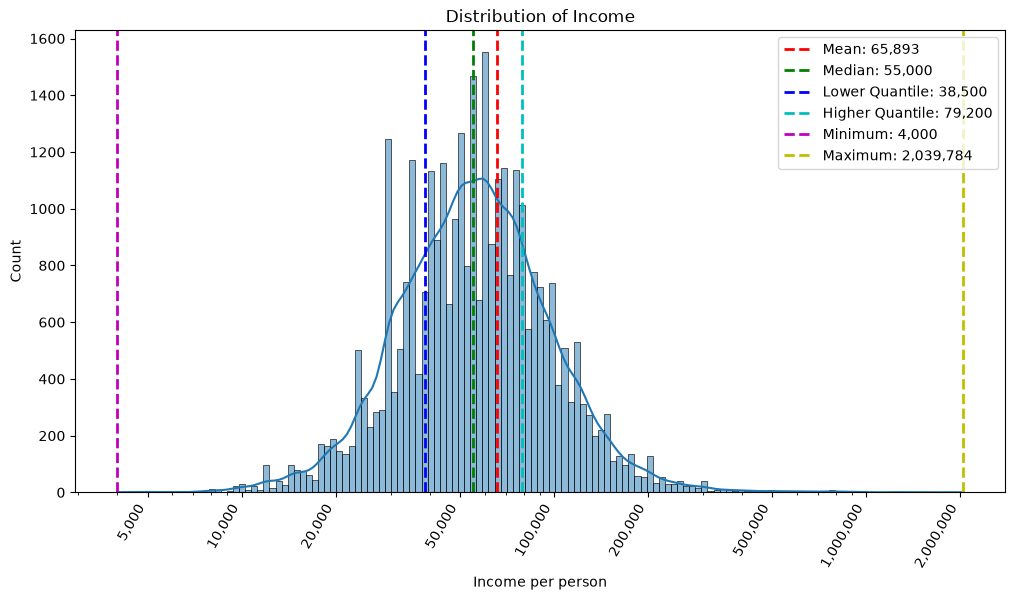

In [10]:
from  matplotlib.ticker import LogLocator
from matplotlib.ticker import FuncFormatter

min_val = person_incomes['Clean_person_income'].min()
max_val = person_incomes['Clean_person_income'].max()

mean_val = person_incomes['Clean_person_income'].mean()
median_val = person_incomes['Clean_person_income'].median()
lower_val = person_incomes['Clean_person_income'].quantile(0.25)
higher_val = person_incomes['Clean_person_income'].quantile(0.75)

plt.figure(figsize=(12,6))
incomes = sb.histplot(person_incomes,
                      x=person_incomes['Clean_person_income'],
                      bins='fd', 
                      stat='count',
                      log_scale=True,
                      kde=True,)
incomes.xaxis.set_major_formatter(FuncFormatter(lambda x, _:f'{int(x):,}'))
incomes.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 5]))

incomes.axvline(mean_val, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_val:,.0f}')
incomes.axvline(median_val, color='g', linestyle='--', linewidth=2, label=f'Median: {median_val:,.0f}')
incomes.axvline(lower_val, color='b', linestyle='--', linewidth=2, label=f'Lower Quantile: {lower_val:,.0f}')
incomes.axvline(higher_val, color='c', linestyle='--', linewidth=2, label=f'Higher Quantile: {higher_val:,.0f}')

incomes.axvline(min_val, color='m', linestyle='--', linewidth=2, label=f'Minimum: {min_val:,.0f}')
incomes.axvline(max_val, color='y', linestyle='--', linewidth=2, label=f'Maximum: {max_val:,.0f}')

incomes.set_xlabel('Income per person')
incomes.set_title('Distribution of Income')
incomes.legend()

plt.xticks(rotation=60, horizontalalignment="right")


The graph shows the distribution of income peaks just between the median and mean values and to the little right of the median. This graph shows that most of the income are concentrated between the lower and higher quantile. Smaller spikes can be observed just before the lower quantile and after the higher quantile. This means that even though most of the borrowers have income located near the median, there are still income far away from it especially the income above the median that pulls the graph to skew right. The average borrower profile used median as the expected income due to the skewness of the distribution. To confirm the skewness, the code below was used:

In [11]:
person_incomes['Clean_person_income'].skew() # Positive means right while negative numbers mean left

np.float64(9.747678448663162)

##### Home Ownership

The column can provide an assessment on how types of home ownership can relate to the ability of borrowers to pay their loans or default on their loans. This data can support borrower profiling, giving a clearer picture to what a typical borrower's profile looks like. To analyze the data, the following code was used:

In [12]:
home_ownerships = pd.read_csv('cleaned_data/cleaned_person_home_ownerships.csv')
home_ownerships.info()
home_ownerships.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Clean_person_home_ownership  32581 non-null  str  
dtypes: str(1)
memory usage: 254.7 KB


,Clean_person_home_ownership
count,32581
unique,4
top,RENT
freq,16446


In [13]:
home_ownerships.drop_duplicates(keep='last')

,Clean_person_home_ownership
32291,OTHER
32572,OWN
32579,MORTGAGE
32580,RENT


There are four types of home ownership in the column. Finding out the most frequent type can help in profiling the average borrower.

Text(0.5, 1.0, 'Distribution of Home Ownerships.')

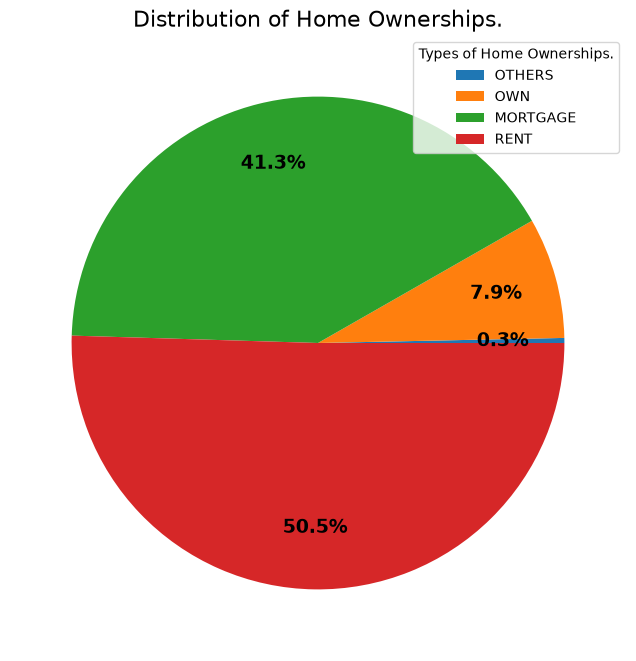

In [14]:
other = home_ownerships[home_ownerships['Clean_person_home_ownership'] == 'OTHER']
own = home_ownerships[home_ownerships['Clean_person_home_ownership'] == 'OWN']
mortgage = home_ownerships[home_ownerships['Clean_person_home_ownership'] == 'MORTGAGE']
rent = home_ownerships[home_ownerships['Clean_person_home_ownership'] == 'RENT']

home_counts = pd.DataFrame([
  other.count(),
  own.count(),
  mortgage.count(),
  rent.count()
],index=['OTHER','OWN','MORTGAGE','RENT'])

home_counts = home_counts.rename(columns={'Clean_person_home_ownership':'Type'})

ownership_labels = ['OTHERS','OWN','MORTGAGE','RENT']


fig, ax = plt.subplots(figsize=(8,8))
pie = ax.pie(home_counts['Type'], autopct='%1.1f%%',
             pctdistance=0.75, 
             textprops=dict(color='black', size=14, weight='bold'))

# Set pie chart legends
ax.legend(pie.wedges,['OTHERS','OWN','MORTGAGE','RENT'],
            title='Types of Home Ownerships.'
           )

# Set pie chart title
ax.set_title('Distribution of Home Ownerships.',  color='Black', fontsize="16")

The graph displays the distribution of home ownerships and based on the result, majority of the borrowers rent `(50.5%)`, followed by mortgage `(41.3%)`, then home ownership `(7.3%)` and others `(0.3%)`. This suggests that the average borrower is renting or paying mortgage for their home instead of owning them outright.

##### Employment Length

The column represents how long is the employment of a borrower in years. The employment length can be used to relate the amount of loan taken which can help the analyst in making an average borrower profile. The followind code was used:

In [15]:
employment_length = pd.read_csv('cleaned_data/cleaned_person_emp_length.csv')
employment_length.info()
employment_length.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Clean_person_emp_length  32581 non-null  float64
dtypes: float64(1)
memory usage: 254.7 KB


,Clean_person_emp_length
count,32581.000000
mean,4.760689
std,3.981013
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,41.000000


The `0` in years could mean either unemployed, self-employed, semi-employed or still working less than a year. The huge gap between the third quantile and maximum value suggests a less concentrated or more spread out distribution of the top 25% of the data.

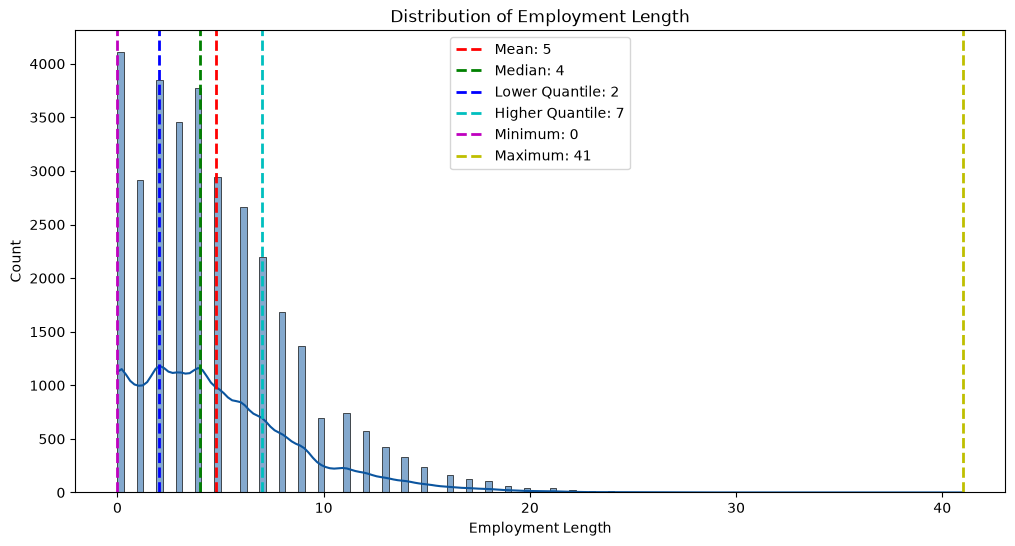

In [16]:
# Make the plot size
plt.figure(figsize=(12,6))
employment_length = employment_length.rename(columns={'Clean_person_emp_length':'Employment Length'}) # Rename column

palette = sb.color_palette("Blues") # Color pallete
bar_color = palette[5]

# Plot the data
emp_length = sb.histplot(employment_length, x='Employment Length', bins='fd', stat='count',kde=True, color=bar_color)

# Get descriptive values
mean_val = employment_length['Employment Length'].mean()
median_val = employment_length['Employment Length'].median()
lower_val = employment_length['Employment Length'].quantile(0.25)
higher_val = employment_length['Employment Length'].quantile(0.75)

min_val = employment_length['Employment Length'].min()
max_val = employment_length['Employment Length'].max()

# Draw lines for descriptive values
emp_length.axvline(mean_val, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_val:,.0f}')
emp_length.axvline(median_val, color='g', linestyle='--', linewidth=2, label=f'Median: {median_val:,.0f}')
emp_length.axvline(lower_val, color='b', linestyle='--', linewidth=2, label=f'Lower Quantile: {lower_val:,.0f}')
emp_length.axvline(higher_val, color='c', linestyle='--', linewidth=2, label=f'Higher Quantile: {higher_val:,.0f}')

emp_length.axvline(min_val, color='m', linestyle='--', linewidth=2, label=f'Minimum: {min_val:,.0f}')
emp_length.axvline(max_val, color='y', linestyle='--', linewidth=2, label=f'Maximum: {max_val:,.0f}')

# Set title and labels
emp_length.set_xlabel('Employment Length')
emp_length.set_title('Distribution of Employment Length')
emp_length.legend()


In [17]:
employment_length['Employment Length'].skew()

np.float64(1.2794011696538354)

The graph shows that borrowers with less than a year of professional employment, or unemployed are the most frequent borrowers. The majority falls below the median of `4` years but the graph shows the mean of `5` years. This is due to the borrowers with longer employment pulling the skewness of the graph to the right. Their presence suggest a higher concentration of shorter employment while still having a group of longer employed borrowers. The skewness suggests that the batter profile to put in the employment length is the median, which is `4` years.

##### Loan Intent

The data shows the purpose or intention behind the loan, indicating what borrowers plan to use the funds for. Analyzing this variable can help understand what the average borrower profile is and can help in analyzing patterns or behaviors of the borrowers. The code used are the following:

In [18]:
loan_intents = pd.read_csv('cleaned_data/cleaned_loan_intent.csv')
loan_intents.info()
loan_intents.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Clean_loan_intent  32581 non-null  str  
dtypes: str(1)
memory usage: 254.7 KB


,Clean_loan_intent
count,32581
unique,6
top,EDUCATION
freq,6453


In [22]:
# Drop duplicates except the last
loan_intents.drop_duplicates(keep='last')

,Clean_loan_intent
32556,DEBT CONSOLIDATION
32571,VENTURE
32575,EDUCATION
32578,HOME IMPROVEMENT
32579,PERSONAL
32580,MEDICAL


In [ ]:
# Get count for each loan intent and store on dataframe
debt_consol = loan_intents[loan_intents['Clean_loan_intent'] == 'DEBT CONSOLIDATION'].count()
venture = loan_intents[loan_intents['Clean_loan_intent'] == 'VENTURE'].count()
education = loan_intents[loan_intents['Clean_loan_intent'] == 'EDUCATION'].count()
home_improv = loan_intents[loan_intents['Clean_loan_intent'] == 'HOME IMPROVEMENT'].count()
personal = loan_intents[loan_intents['Clean_loan_intent'] == 'PERSONAL'].count()
medical = loan_intents[loan_intents['Clean_loan_intent'] == 'MEDICAL'].count()
df_intents = pd.DataFrame(
  [
    debt_consol,
    venture,
    education,
    home_improv,
    personal,
    medical
  ], index=['DEBT CONSOLIDATION','VENTURE','EDUCATION','HOME IMPROVEMENT','PERSONAL','MEDICAL']
)

# Rename column
df_intents = df_intents.rename(columns={'Clean_loan_intent':'Count'})

Text(0.5, 1.0, 'Distribution of Types of Loan Intent')

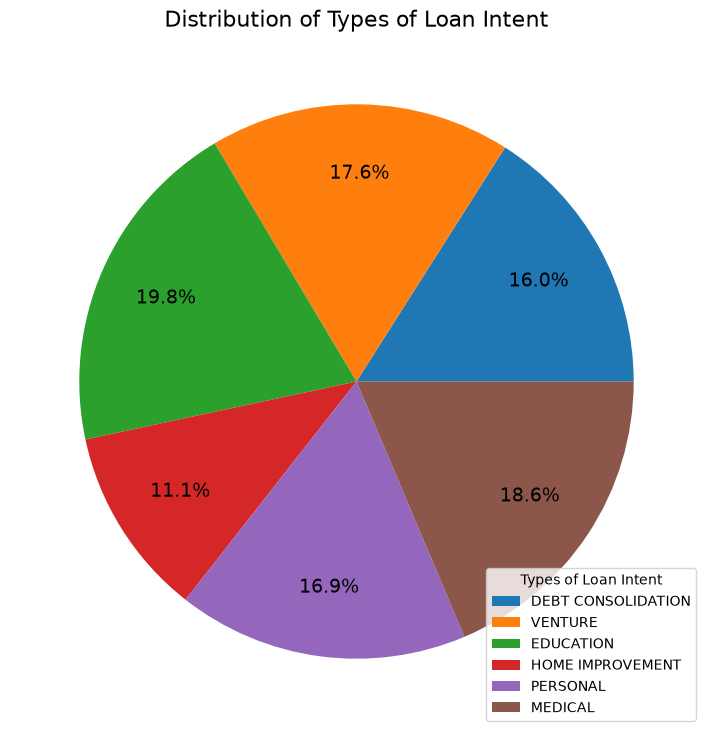

In [ ]:
# Labels array
intent_labels = np.array(['DEBT CONSOLIDATION','VENTURE','EDUCATION','HOME IMPROVEMENT','PERSONAL','MEDICAL'])

# Create the plot
fig, ax = plt.subplots(figsize=(9,9))

# Draw pie chart
pie = ax.pie(df_intents['Count'], autopct='%1.1f%%',
             pctdistance=0.75, 
             textprops=dict(color='black', size=14))

# Add legends usign the labels
ax.legend(pie.wedges,intent_labels,
            title='Types of Loan Intent'
           )

# Set title
ax.set_title('Distribution of Types of Loan Intent', color='Black', fontsize="16")

The leading reason for loaning is `EDUCATION (19.8%)` followed closely by `MEDICAL (18.6%)`, `VENTURE (17.6%)`, `PERSONAL (16.9%)`, `DEBT CONSOLIDATION (16.0%)` and lastly, `HOME IMPROVEMENT (11.1%)`. The smaller differences between the percentages suggests that the borrower's intention are varied therefore, there is no clear single answer to what an average borrower may use the loan for. The borrower profile will instead make it clear that any of the reasons presented are possible.

##### Loan Grade


Since no official description for the loan grades where stated, the analyst used the following:
| Grade | Description |
|---|---|
| A | No to Very low Risk |
| B | Low Risk |
| C | Average Risk |
| D | Moderate Risk |
| E | High Risk |
| F | Very High Risk|
| G | Highest Risk |

The data represents the grade of the borrower. This grade refers to the likelihood of a borrower to completely pay off their loans of time. The grade ranges alphabetically from `A` to `G`, with A being the lower risk and G being the most likely to default. The code below shows how the column was analyzed:

In [ ]:
loan_grades = pd.read_csv('cleaned_data/cleaned_loan_grade.csv')
loan_grades.info()
loan_grades.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Clean_loan_grade  32581 non-null  str  
dtypes: str(1)
memory usage: 254.7 KB


,Clean_loan_grade
count,32581
unique,7
top,A
freq,10777


In [ ]:
# Dropp duplicates except the last
loan_grades.drop_duplicates(keep='last')

,Clean_loan_grade
32071,G
32555,F
32563,E
32574,D
32576,C
32577,A
32580,B


The results shows the seven types of loan grades. To determine their distribution, the following code was used:

In [ ]:
# lables for grades
main_labels = np.array([
  'A',
  'B',
  'C',
  'D',
  'E',
  'F',
  'G'
])

# Get all counts for each grade
A_grades = loan_grades[loan_grades['Clean_loan_grade'] == 'A'].count()
B_grades = loan_grades[loan_grades['Clean_loan_grade'] == 'B'].count()
C_grades = loan_grades[loan_grades['Clean_loan_grade'] == 'C'].count()
D_grades = loan_grades[loan_grades['Clean_loan_grade'] == 'D'].count()
E_grades = loan_grades[loan_grades['Clean_loan_grade'] == 'E'].count()
F_grades = loan_grades[loan_grades['Clean_loan_grade'] == 'F'].count()
G_grades = loan_grades[loan_grades['Clean_loan_grade'] == 'G'].count()

# Store counts on a dataframe
count_grades = pd.DataFrame([
  A_grades,
  B_grades,
  C_grades,
  D_grades,
  E_grades,
  F_grades,
  G_grades
], index=main_labels)

# Rename axis and column
count_grades = count_grades.rename(columns={'Clean_loan_grade':'Count'})
count_grades = count_grades.rename_axis('Grades')
count_grades

,Count
Grades,
A,10777
B,10451
C,6458
D,3626
E,964
F,241
G,64


[Text(0, 10, '10'),
 Text(0, 100, '100'),
 Text(0, 1000, '1,000'),
 Text(0, 10000, '10,000'),
 Text(0, 100000, '100,000')]

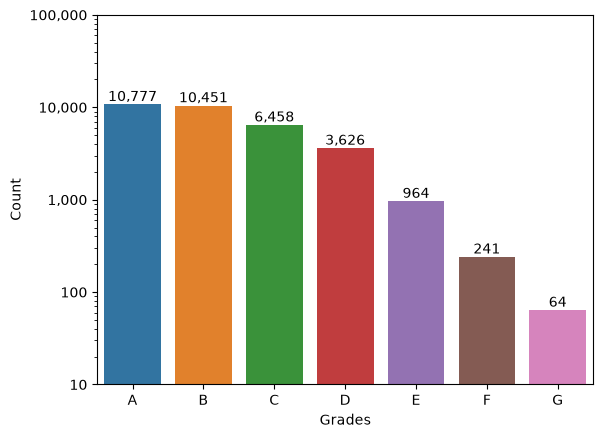

In [ ]:
# Plot barchart
ax = sb.barplot(count_grades, x='Grades',y='Count', hue='Grades', legend=False)

# For each bar, show the count
for container in ax.containers:
  ax.bar_label(container, fmt=lambda x: f'{int(x):,}')

# Scale the barchart
ax.set_yscale('log')

#Show specific y-ticks
ticks = [10, 100, 1000, 10000, 100000]
ax.set_yticks(ticks)
ax.set_yticklabels(['10', '100', '1,000', '10,000', '100,000'])

In [ ]:
# Display the percentages
for grade in count_grades['Count']:
  average = (count_grades['Count'] / count_grades['Count'].sum())
  count_grades['Percentage'] = average.apply(lambda x: format(x, '.2%'))

count_grades

,Count,Percentage
Grades,,
A,10777,33.08%
B,10451,32.08%
C,6458,19.82%
D,3626,11.13%
E,964,2.96%
F,241,0.74%
G,64,0.20%


The results show that the grades with the most borrowers are `A (33.08%)` followed closely by B `(32.08%)`, with a small gap between them. The two are then followed by the rest in the following order: `C (19.82%)`, `D (11.13%)`, `E (2.96%)`, `F (0.74%)`, and `G (0.20%)`. Since A and B together account for approximately 65% of all borrowers, it is reasonable to conclude that the average borrower falls between these two grades.

##### Loan Amount

This column represents the amount a borrower has loaned from the company. The results of this analysis can help in analyzing the average loan amount per age groups and provide a basis for an average borrower profile. The following code was used:

In [ ]:
loan_amounts = pd.read_csv('cleaned_data/cleaned_loan_amnt.csv')
loan_amounts.info()
loan_amounts.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Clean_loan_amnt  32581 non-null  int64
dtypes: int64(1)
memory usage: 254.7 KB


,Clean_loan_amnt
count,32581.000000
mean,9589.371106
std,6322.086646
min,500.000000
25%,5000.000000
50%,8000.000000
75%,12200.000000
max,35000.000000


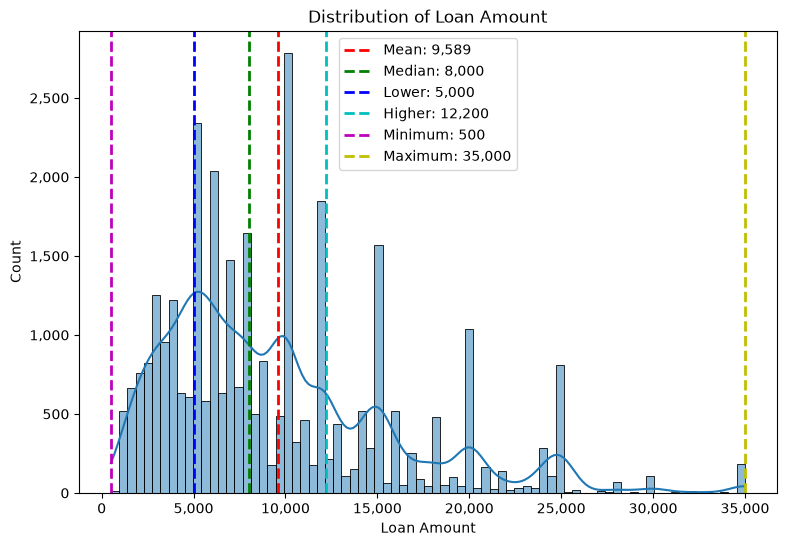

In [ ]:
# Rename axis and column
loan_amounts = loan_amounts.rename_axis('Count')
loan_amounts = loan_amounts.rename(columns={'Clean_loan_amnt':'Amount'})

# Get descriptive values
mean_val = loan_amounts['Amount'].mean()
median_val = loan_amounts['Amount'].median()
lower_val = loan_amounts['Amount'].quantile(0.25)
higher_val = loan_amounts['Amount'].quantile(0.75)

min_val = loan_amounts['Amount'].min()
max_val = loan_amounts['Amount'].max()

# Create the plot
fig, ax = plt.subplots(figsize=(9,6))

# Plot the histogram
amount_chart = sb.histplot(loan_amounts,
            kde=True,
            bins='fd',
            stat='count'
            )

# Draw the lines for descriptive values
amount_chart.axvline(mean_val, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_val:,.0f}')
amount_chart.axvline(median_val, color='g', linestyle='--', linewidth=2, label=f'Median: {median_val:,.0f}')
amount_chart.axvline(lower_val, color='b', linestyle='--', linewidth=2, label=f'Lower: {lower_val:,.0f}')
amount_chart.axvline(higher_val, color='c', linestyle='--', linewidth=2, label=f'Higher: {higher_val:,.0f}')
amount_chart.axvline(min_val, color='m', linestyle='--', linewidth=2, label=f'Minimum: {min_val:,.0f}')
amount_chart.axvline(max_val, color='y', linestyle='--', linewidth=2, label=f'Maximum: {max_val:,.0f}')

amount_chart.xaxis.set_major_formatter(FuncFormatter(lambda x, _:f'{int(x):,}'))
amount_chart.yaxis.set_major_formatter(FuncFormatter(lambda x, _:f'{int(x):,}'))

# Set title, x label, and legend
amount_chart.set_title('Distribution of Loan Amount')
amount_chart.set_xlabel('Loan Amount')
amount_chart.legend()


In [ ]:
loan_amounts['Amount'].skew()

np.float64(1.1924774277661998)

The graph shows the distribution of loan amounts and the most loaned amount is around $10,000 which is close to the mean. The presence of loans higher than the third quartile pulls the graph to skew right. One pattern that can be observed are the amount of borrowers which spikes every $5,000. The higher density occurs around the lower quartile while the highest count is found near the mean. This means that the lower quartile has the densest range of values while the most occurring value is near the mean which is $10,000. Due to the right-skewness of the distribution, it is better to conclude that the average borrower profile has the loan amount of the median, which is $8,000.

##### Loan Interest Rate

The interest rate refers to percentage that the a bank charges based on the loan amount. These charges are then added to the base loan amount every month and is the main basis for banks to profit. This is a valuable data that can help in analysing the average borrower profile. The analyst used the following code to analyze the data:

In [ ]:
interest_rates = pd.read_csv('cleaned_data/cleaned_loan_int_rate.csv')
interest_rates.info()
interest_rates.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Clean_loan_int_rate  32581 non-null  float64
dtypes: float64(1)
memory usage: 254.7 KB


,Clean_loan_int_rate
count,32581.000000
mean,11.011830
std,3.085959
min,3.951244
25%,8.490000
50%,10.990000
75%,13.110000
max,23.220000


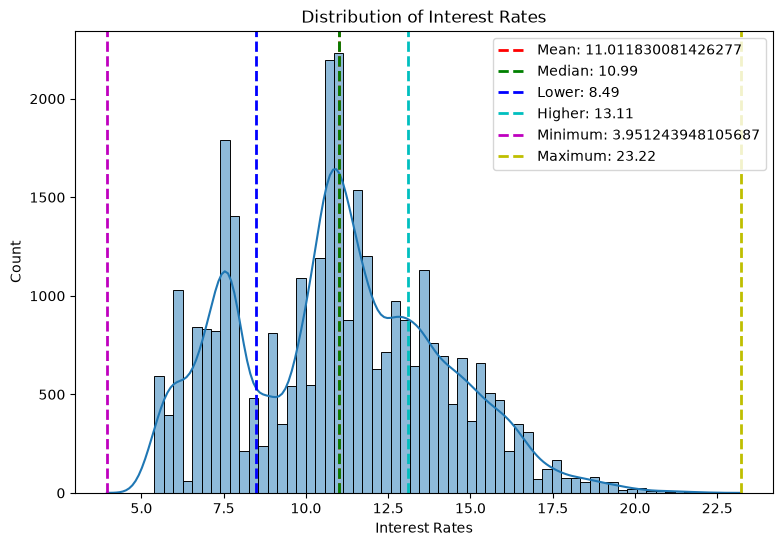

In [ ]:
# Rename axis and columns
interest_rates = interest_rates.rename_axis('Count')
interest_rates = interest_rates.rename(columns={'Clean_loan_int_rate':'Interest Rate'})

# Get descriptive values
mean_val = interest_rates['Interest Rate'].mean()
median_val = interest_rates['Interest Rate'].median()
lower_val = interest_rates['Interest Rate'].quantile(0.25)
higher_val = interest_rates['Interest Rate'].quantile(0.75)

min_val = interest_rates['Interest Rate'].min()
max_val = interest_rates['Interest Rate'].max()

# Create the plot
plt.subplots(figsize=(9,6))

# Plot the histogram
int_rates = sb.histplot(
  interest_rates,
  bins='fd',
  kde=True,
  stat='count'
  )

# Draw lines for descriptive values
int_rates.axvline(mean_val, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_val}')
int_rates.axvline(median_val, color='g', linestyle='--', linewidth=2, label=f'Median: {median_val}')
int_rates.axvline(lower_val, color='b', linestyle='--', linewidth=2, label=f'Lower: {lower_val}')
int_rates.axvline(higher_val, color='c', linestyle='--', linewidth=2, label=f'Higher: {higher_val}')
int_rates.axvline(min_val, color='m', linestyle='--', linewidth=2, label=f'Minimum: {min_val}')
int_rates.axvline(max_val, color='y', linestyle='--', linewidth=2, label=f'Maximum: {max_val}')

# Set title, x label, and legend
int_rates.set_title('Distribution of Interest Rates')
int_rates.set_xlabel('Interest Rates')
int_rates.legend()

In [ ]:
interest_rates['Interest Rate'].skew()

np.float64(0.21818618916153243)

The code to anaylze the skewness reveals a graph that is slightly right-skewed in their distribution with the mean `(11.01183008142677%)` only having a little difference with the median `(10.99%)`. The highest spike is located close to the median and mean, with a noticeable smaller spike just before the lower quartile. Due to the small gap between the mean and median, the more reasonable average interest rate for the average borrower profile would be `11%`.

##### Loan Status

The data represents the current status of the loan. The data is stored as boolean objects of `True` or `False` where `True` means that the loan is still active while `False` means it is inactive. An 'active' loan means the borrower still owes money to the loaner while 'inactive' means that the loan has either already been paid, settled, dischared, or written off. A loan can still be active even if it is already defaulted. The data can help in making an average borrower profile by providing if the average loan is still active or not. The analyst used the following code to further analyze the column:

In [ ]:
loan_statuses = pd.read_csv('cleaned_data/cleaned_loan_status.csv')
loan_statuses.info()
loan_statuses.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Clean_loan_status  32581 non-null  bool 
dtypes: bool(1)
memory usage: 31.9 KB


,Clean_loan_status
count,32581
unique,2
top,False
freq,25473


In [ ]:
# Rename axis and column
loan_statuses = loan_statuses.rename_axis('Count')
loan_statuses = loan_statuses.rename(columns={'Clean_loan_status':'Status'})

# Get the count for each type
true_count = loan_statuses[loan_statuses['Status']].count()
false_count = loan_statuses[~loan_statuses['Status']].count()

# Store the counts in the dataframe
status_counts = pd.DataFrame([
  true_count,
  false_count
], index=['True','False']
)

# Rename axis and column of new dataframe
status_counts = status_counts.rename_axis('Status')
status_counts = status_counts.rename(columns={'Status':'Count'})

status_counts

,Count
Status,
True,7108
False,25473


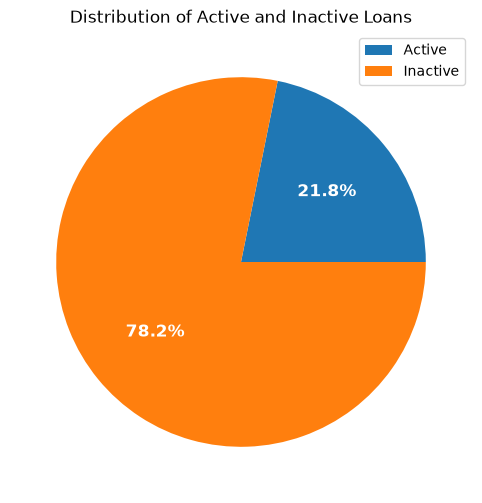

In [ ]:
# Create the plot
fig, ax = plt.subplots(figsize=(9,6))

# Plot the pie chart
pie = ax.pie(
  status_counts['Count'],
  autopct='%1.1f%%',
  textprops=dict(color='w',fontsize=12, weight='bold')
  )

# Set title and legend
ax.set_title('Distribution of Active and Inactive Loans')
ax.legend(labels=['Active','Inactive'])

The pie graph suggests that majority of the loans `78.2%` are inactive with a `21.8%` percentage of remaining loans being active. Based on the data, it is clear that the average borrower already has their loans inactive with a smaller part of them still being active.

##### Loan Percent Income

The data represents the DTI (Debt-to-Income) Ratio which refers to the percentage of a person's gross monthly income that goes into paying off a loan. Analyzing this data is necessary when identifying its relationship with loans being defaulted and is also important in creating an average borrower profile. The analyst used the following code below for the analysis:

In [ ]:
dtis = pd.read_csv('cleaned_data/cleaned_loan_percent_income.csv')
dtis.info()
dtis.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Clean_loan_percent_income  32581 non-null  float64
dtypes: float64(1)
memory usage: 254.7 KB


,Clean_loan_percent_income
count,32581.000000
mean,0.170203
std,0.106782
min,0.000000
25%,0.090000
50%,0.150000
75%,0.230000
max,0.830000


In [ ]:
#Rename axis and column
dtis = dtis.rename_axis('Count')
dtis = dtis.rename(columns={'Clean_loan_percent_income':'Percent'})

dtis_percent = dtis.copy() # Copy datafrane
dtis_percent['Percent'] = dtis_percent['Percent'] * 100 # Multiply the values by 100

# Get info and summary
dtis_percent.info()
dtis_percent.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Percent  32581 non-null  float64
dtypes: float64(1)
memory usage: 254.7 KB


,Percent
count,32581.000000
mean,17.020349
std,10.678176
min,0.000000
25%,9.000000
50%,15.000000
75%,23.000000
max,83.000000


Text(0.5, 1.0, 'Distribution of DTI')

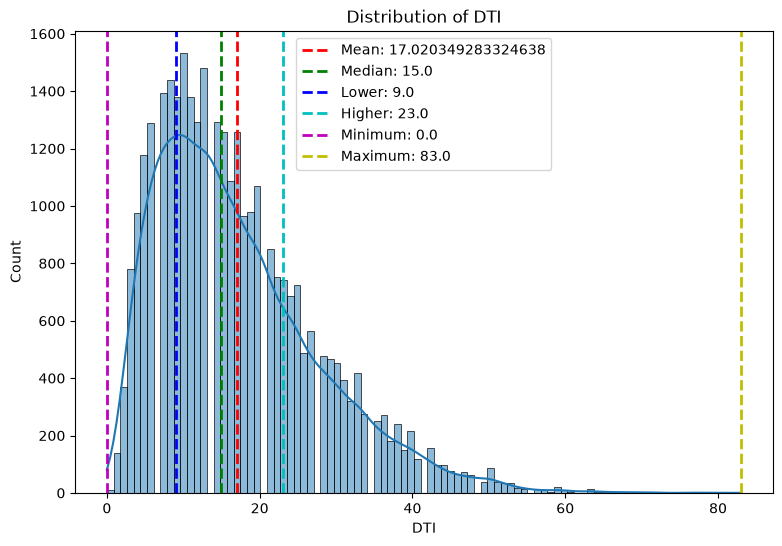

In [ ]:
# Create the plot
fig, ax = plt.subplots(figsize=(9,6))

# Get the descriptive valies
mean_val = dtis_percent['Percent'].mean()
median_val = dtis_percent['Percent'].median()
lower_val = dtis_percent['Percent'].quantile(0.25)
higher_val = dtis_percent['Percent'].quantile(0.75)

min_val = dtis_percent['Percent'].min()
max_val = dtis_percent['Percent'].max()

# Plot the histogram
dti_chart = sb.histplot(dtis_percent, x='Percent', bins='fd', kde=True, stat='count')

# Draw the line for the descriptive values
dti_chart.axvline(mean_val, color='r', linestyle='--', linewidth='2', label = f'Mean: {mean_val}')
dti_chart.axvline(median_val, color='g', linestyle='--', linewidth='2', label = f'Median: {median_val}')
dti_chart.axvline(lower_val, color='b', linestyle='--', linewidth='2', label = f'Lower: {lower_val}')
dti_chart.axvline(higher_val, color='c', linestyle='--', linewidth='2', label = f'Higher: {higher_val}')
dti_chart.axvline(min_val, color='m', linestyle='--', linewidth='2', label = f'Minimum: {min_val}')
dti_chart.axvline(max_val, color='y', linestyle='--', linewidth='2', label = f'Maximum: {max_val}')

# Set the legend, x-label, and title
dti_chart.legend()
dti_chart.set_xlabel('DTI')
dti_chart.set_title('Distribution of DTI')

The graph presents a right-skewed distribution with the only spike being near the lower quartile `(9.0%)` and the tail extending up to the maximum value of `83.0%`. The median can be considered as the average DTI for the profiling which in this case, is `15.0%` as the mean can be affected by outliers.

##### Loan Default on File

The data represents whether the loan has been considered defaulted or not. The data are stored as boolean objects of `True` for defaulted or `False` for not defaulted. The data is important as it can be used to determine the rate of defaulting and be used to correlate with the DTI ratio. The data can also be used in creating a profile for the average borrower and their loan. The analyst used the following code to anaylze the data:

In [ ]:
loan_defaults = pd.read_csv('cleaned_data/cleaned_cb_person_default_on_file.csv')
loan_defaults.info()
loan_defaults.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Clean_cb_person_default_on_file  32581 non-null  bool 
dtypes: bool(1)
memory usage: 31.9 KB


,Clean_cb_person_default_on_file
count,32581
unique,2
top,False
freq,26836


In [ ]:
# Rename column and axis
loan_defaults = loan_defaults.rename_axis('Count')
loan_defaults = loan_defaults.rename(columns={'Clean_cb_person_default_on_file':'Default Status'})
loan_defaults.head()

,Default Status
Count,
0,True
1,False
2,False
3,False
4,True


In [ ]:
# Get the count
defaulted_count = loan_defaults[loan_defaults['Default Status']].count()
not_defaulted_count = loan_defaults[~loan_defaults['Default Status']].count()

# Store the values in the dataframe
defaults_chart = pd.DataFrame([
  defaulted_count,
  not_defaulted_count
], index=['Defaulted','Not Defaulted']
)

defaults_chart

,Default Status
Defaulted,5745
Not Defaulted,26836


Text(0.5, 1.0, 'Distribution of Default Status')

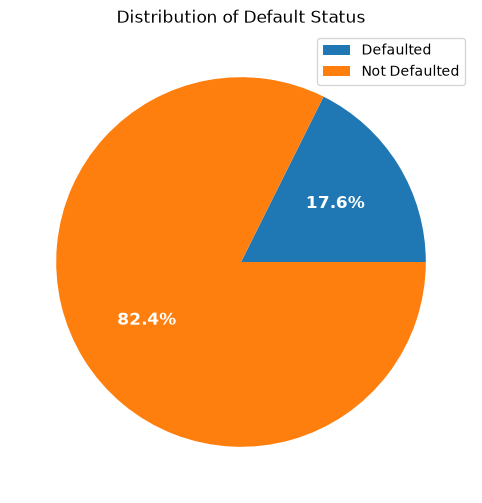

In [ ]:
# Create the plot
fig, ax = plt.subplots(figsize=(9,6))

# Plot the pie chart
pie = ax.pie(
  defaults_chart['Default Status'],
  autopct='%1.1f%%',
  textprops=dict(color='w', fontsize=12, weight='bold')
  )

# Set legend and title
ax.legend(labels=['Defaulted','Not Defaulted'])
ax.set_title('Distribution of Default Status')

The graph shows the distribution of defaulted and not defaulted loans. Non defaulted loans are prominent with `82.4%` while the re,remaining `17.6%` are defaulted. This suggests that the average borrower has not defaulted, making 'Not Defaulted' a fitting profile for the average borrower.

##### Credit History Length

The data represents the length in years the borrower has been loaning. The data can be useful for determining if the credit history length is related to the amount of loan borrowed. It is also useful in determining how long does an average borrower have in their credit history. The analyst used the following code:

In [ ]:
credit_histories = pd.read_csv('cleaned_data/cleaned_cb_person_cred_hist_length.csv')
credit_histories.info()
credit_histories.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Clean_cb_person_cred_hist_length  32581 non-null  int64
dtypes: int64(1)
memory usage: 254.7 KB


,Clean_cb_person_cred_hist_length
count,32581.000000
mean,5.804211
std,4.055001
min,2.000000
25%,3.000000
50%,4.000000
75%,8.000000
max,30.000000


Text(0.5, 1.0, 'Distribution of Credit History')

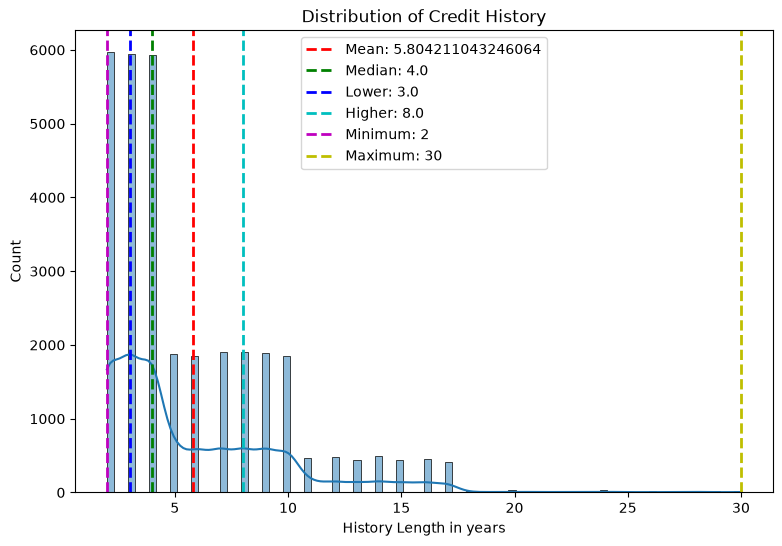

In [ ]:
# Rename axis and column
credit_histories = credit_histories.rename_axis('Count')
credit_histories = credit_histories.rename(columns={'Clean_cb_person_cred_hist_length':'Length'})

# Create the plot
fig, ax = plt.subplots(figsize=(9,6))

# Get the descriptive values
mean_val = credit_histories['Length'].mean()
median_val = credit_histories['Length'].median()
lower_val = credit_histories['Length'].quantile(0.25)
higher_val = credit_histories['Length'].quantile(0.75)

min_val = credit_histories['Length'].min()
max_val = credit_histories['Length'].max()

# Plot the histogram
history_chart = sb.histplot(credit_histories, x='Length',bins='fd', kde=True, stat='count')

# Draw the lines for the descriptive values
history_chart.axvline(mean_val, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_val}')
history_chart.axvline(median_val, color='g', linestyle='--', linewidth=2, label=f'Median: {median_val}')
history_chart.axvline(lower_val, color='b', linestyle='--', linewidth=2, label=f'Lower: {lower_val}')
history_chart.axvline(higher_val, color='c', linestyle='--', linewidth=2, label=f'Higher: {higher_val}')
history_chart.axvline(min_val, color='m', linestyle='--', linewidth=2, label=f'Minimum: {min_val}')
history_chart.axvline(max_val, color='y', linestyle='--', linewidth=2, label=f'Maximum: {max_val}')

# Set the title, x label, and legends
history_chart.set_xlabel('History Length in years')
history_chart.legend()
history_chart.set_title('Distribution of Credit History')

The graph presents a right-skewed distribution of credit history length where the tail is spread out due to the occurance of longer history length but lower number of responses. The number of borrowers significantly dropped just before `5` years and also dropped after the `10` years. The higher density in the lower lengths suggests newer borrowers with only a few years of history. The median is considered the average history length for the borrower profiling with a value of `4` years.

#### Answering Queries

##### 1. What is the overall default rate in our dataset?

To calculate for the default rate, simply divide the number of defaulted loans over the total loans to get the default rate and conduct a z-test.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Get the default rate by:
# number of defaults / total number of rows
defaulted_loans = loan_defaults[loan_defaults['Default Status']].count()
default_rate = (defaulted_loans / loan_defaults['Default Status'].count())

# Get the z-stat and p-value using the library
z_stat, p_value = proportions_ztest(
  count=defaulted_loans,
  nobs=loan_defaults['Default Status'].count(),
  value=0.20,
  alternative='smaller')

# Print the results
print(f'The observed default rate is {default_rate['Default Status']:.2%}')
print(f'The z-stat is {z_stat}')
print(f'The p-value is {p_value}')


The observed default rate is 17.63%
The z-stat is [-11.21102491]
The p-value is [1.80000203e-29]


The oberved rate is `17.63%` and after conducting a z-test where the 20% is the benchmark, it can be concluded that the observed rate is unlikely if the true rate is greater than or equal to `20%`.

*Ho*: The default rate is greater than or equal to `20%`.  
*Ha*: The default rate is less than `20%`.  
*Conclusion*: The default rate is `17.63%` which makes the alternative hypothesis favorable and reject the null hypothesis.

##### 2. How does the DTI (Debt to Income) ratio correlate with the likelihood of defaulted loans? 

The relationship between the DTI and likelihood of default loans can be examined using Pearson's r. The analyst used the following code:

Text(0.5, 1.0, 'Relationship of DTI and Default Status')

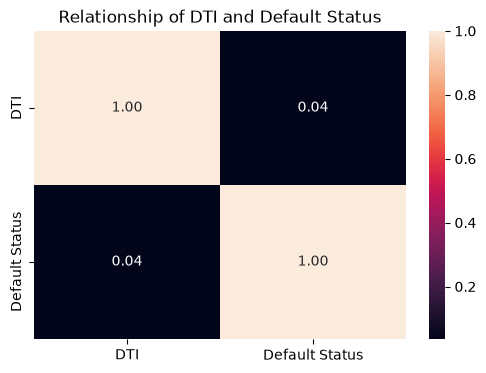

In [ ]:
# Load dataset and assign the needed variables
dataset = pd.read_csv('cleaned_credit_risk_dataset.csv')
pearson = dataset[[
  'Clean_loan_percent_income',
  'Clean_cb_person_default_on_file'
  ]].corr(method='pearson')

# Change column and index names
pearson = pearson.rename(columns={
  'Clean_loan_percent_income':'DTI',
  'Clean_cb_person_default_on_file':'Default Status'
  })
pearson = pearson.rename(index={
  'Clean_loan_percent_income':'DTI',
  'Clean_cb_person_default_on_file':'Default Status'
  })

# Create a heatmap
fig, ax = plt.subplots(figsize=(6,4))
sb.heatmap(pearson, annot=True, fmt='.2f')
ax.set_title('Relationship of DTI and Default Status')


Based on the heatmap, the linear relationship between the two variable are very small. To further analyze the data, the analyst used the following code to determine the non-linear relationship between the two variables:

Text(0.5, 1.0, 'Non-linear relationship of DTI and Default Status')

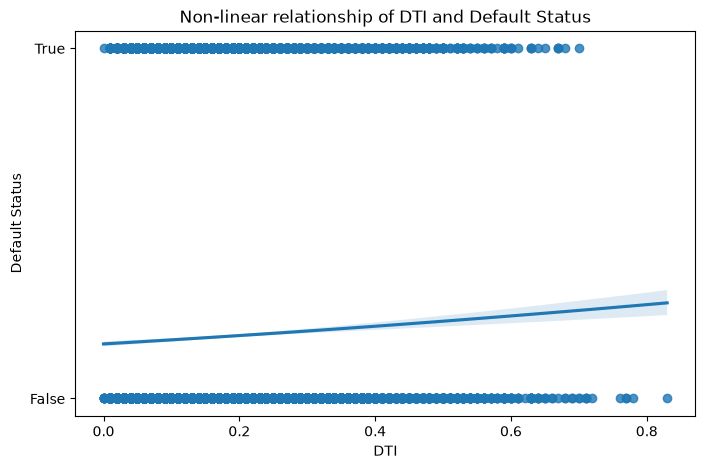

In [ ]:
# Create a logistical regression plot
fig, ax= plt.subplots(figsize=(8, 5))
sb.regplot(data=dataset, x='Clean_loan_percent_income', 
            y='Clean_cb_person_default_on_file', 
            logistic=True)

# Set ticks
ax.set_yticks([0,1])
ax.set_yticklabels(['False', 'True'])

# Set labels and title
ax.set_ylabel('Default Status')
ax.set_xlabel('DTI')
ax.set_title('Non-linear relationship of DTI and Default Status')

The logistic regression chart shows that there is a small increase in the number of defaulted loans as the DTI goes higher. This implicates that high DTI still positively affects the number of defaulted loans, albeit only having a small influence.

*Ho*: There is no relationship between the DTI and the likelihood of defaulting.  
*Ha*: There is a relationship between the DTI and the likelihood of defaulting.  
*Conclusion*: The rise of the curve as the DTI increases supports that the alternative hypothesis is favorable while the null hypothesis is rejected.

##### 3. What would an average borrower profile look like?

The data analysis provided several insights regarding the profile of an average borrower. The analyst used the following code to discover the results:

* `AGE`: The age of the borrowers are analyzed as age groups. This is more useful as age groups are better for analyzing trends. The median is still calculated and displayed to get the precise age. The analysis of the ages is done here: [Age](#age)
* `INCOME`: The income of the borrowers are analyzed and their distributions are examined. The analysis of the incomes is done here: [Income](#income)
* `HOME OWNERSHIP`: The different types of home ownership and how many borrower are under their categories are analyzed in this section: [Home Ownership](#home-ownership)
* `EMPLOYMENT LENGTH`: The employment length is measured in years and is analyzed in this section: [Employment Length](#employment-length)
* `LOAN INTENT`: The purpose for loaning is analyzed in the part: [Loan Intent](#loan-intent)
* `LOAN GRADE`: The loan grades for A to G are analyzed in this section: [Loan Grades](#loan-grade)
* `LOAN AMOUNT`: The amount loaned are analyzed in this part of the notebook: [Loan Amount](#loan-amount)
* `LOAN STATUS`: The status of the loan are analyzed in this part: [Loan Status](#loan-status)
* `DTI`: The DTI for each borrower are analyzed in this section: [Loan Percent Income](#loan-percent-income)
* `DEFAULT STATUS`: The default status of each loan is analyzed in this section: [Loan Default on File](#loan-default-on-file)
* `CREDIT HISTORY LENGTH`: The credit history length of each borrower are analyzed in the part: [Credit History Length](#credit-history-length)


In [ ]:
from itertools import count


print('1. AGE')
print('The age groups are the following: ')
print(age_groups)
print(f'The median age of the borrowers is {int(person_ages['Clean_person_age'].median())} yrs old')
print('\n')

print('2. INCOME')
print(f'The median income for a borrower is ${person_incomes['Clean_person_income'].median()}')
print('\n')

print('3. HOME OWNERSHIP')
print('The type of home ownerships and their counts are: ')
home_counts = home_counts.rename_axis('Type')
home_counts = home_counts.rename(columns={'Type':'Count'})
home_counts = home_counts.sort_values(by='Count', ascending=False)
print(home_counts)
print(f'The most frequent type of home ownership is {home_counts.iloc[0].name}')
print(f'Followed closely by {home_counts.iloc[1].name}')
print('\n')

print('4. Employment Length')
print(f'The typical employment length of a borrower is {int(employment_length['Employment Length'].median())} years')
print('\n')

print('5. Loan Intent')
print('The purpose of loan and their counts are: ')
df_intents = df_intents.sort_values('Count', ascending=False)
print(df_intents)
print(f'The most frequent intent for loaning is for {df_intents.iloc[0].name}')
print(f'Followed closely by {df_intents.iloc[1].name}')
print('\n')

print('6. Loan Grade')
print('The loan grades and their counts are: ')
print(count_grades)
print(f'The most frequent grade is {count_grades.iloc[0].name}')
print(f'Followed closely by {count_grades.iloc[1].name}')
print('\n')

print('7. Loan Amount')
print(f'The typical loan amount is ${loan_amounts['Amount'].median()}')
print('\n')

print('8. Interest Rate')
print(f'The typical interest rate is {interest_rates['Interest Rate'].median()}%')
print('\n')

print('9. Loan status')
print('The status of the loans are: ')
status_counts = status_counts.sort_values('Count', ascending=False)
print(status_counts)
if status_counts.iloc[0].name == True:
  print('The typical loan is Active')
else:
  print('The typical loan is Inactive')
print('\n')

print('10. DTI')
print(f'The typical DTI is {dtis_percent['Percent'].median()}%')
print('\n')

print('11. Default Status')
print('The default status of the loans and their counts are: ')
print(defaults_chart)
print(f'The typical loan is {defaults_chart.iloc[0].name}')
print('\n')

print('12. Credit History Length')
print(f'The typical borrower has a credit history of {int(credit_histories['Length'].median())} years')

1. AGE
The age groups are the following: 
           Count
Age Group       
18-25      15354
26-40      15735
41-55       1358
56-65        104
66+           30
The median age of the borrowers is 26 yrs old


2. INCOME
The median income for a borrower is $55000.0


3. HOME OWNERSHIP
The type of home ownerships and their counts are: 
          Count
Type           
RENT      16446
MORTGAGE  13444
OWN        2584
OTHER       107
The most frequent type of home ownership is RENT
Followed closely by MORTGAGE


4. Employment Length
The typical employment length of a borrower is 4 years


5. Loan Intent
The purpose of loan and their counts are: 
                    Count
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBT CONSOLIDATION   5212
HOME IMPROVEMENT     3605
The most frequent intent for loaning is for EDUCATION
Followed closely by MEDICAL


6. Loan Grade
The loan grades and their counts are: 
        Count Percentage
Grades   

*Conclusion*: The average borrowers would be around 26 years old, inside the most frequent age brackets of 18-25 and 26-40. They would have an income of 55,000. They are either renting or paying mortgage for their homes. They are employed for 4 years and their purpose for loaning is quite varied and shows no single dominant intent, therefore the purpose does not have a definite answer. Their loan grade would either be A or B. They would loan $8000 with an interest rate of 10.99%. Their loans are mostly paid off with their DTI ratio being 15%. They have a credit history of 4 years.

##### 4. What is the average loan amount requested per age group?

To answer this question, the analyst divided the borrower ages into several groups and determined the average income for each. The following code was used:

In [ ]:
# Using this function, it will return the average income from x tp y

from pandas import DataFrame as dataframe

def return_avg_income(df: dataframe, column :str, x :int, y :int):
  results = df[(df[column] >= x) & (df[column] <= y)]
  return results['Clean_person_income'].mean()

In [ ]:
age_income_df = pd.read_csv('cleaned_credit_risk_dataset.csv') # Impoty dataset
age_income_df = age_income_df[['Clean_person_age','Clean_person_income']] # Only get age and income

# Get the average mean for each age group
group_18to25 = return_avg_income(df = age_income_df, column='Clean_person_age', x=18, y=25)
group_26to40 = return_avg_income(df = age_income_df, column='Clean_person_age', x=26, y=40)
group_41to55 = return_avg_income(df = age_income_df, column='Clean_person_age', x=41, y=55)
group_56to65 = return_avg_income(df = age_income_df, column='Clean_person_age', x=56, y=65)
group_65plus = return_avg_income(df = age_income_df, column='Clean_person_age', x=66, y=999)

# Store the averages in a dataframe
avg_incomes = pd.DataFrame([
  f'${group_18to25:,.2f}',
  f'${group_26to40:,.2f}',
  f'${group_41to55:,.2f}',
  f'${group_56to65:,.2f}',
  f'${group_65plus:,.2f}'
], index=['18-25','26-40','41-55','56-65','66+'], columns=['Average Income']
)

# Rename axis
avg_incomes = avg_incomes.rename_axis('Age Group')

avg_incomes

,Average Income
Age Group,
18-25,"$58,961.08"
26-40,"$71,017.13"
41-55,"$80,246.68"
56-65,"$126,078.61"
66+,"$67,147.87"


The average income increases as the age group gets older however, the average income peaks at the `56-65` age group then it fall down on the next age group.

*Ho*: The average income for each age group does not vary.  
*Ha*: The average income increases the higher the age group.  
*Conclusion*: The null hypothesis can be rejected while the alternative hypothesis can be partially supported as the average income did increase but only up to a certain age group.

##### 5. Do borrowers with longer credit history borrow more money?

The analyst answered this question using a Pearson's r and displayed using a heatmap. The following code was used:

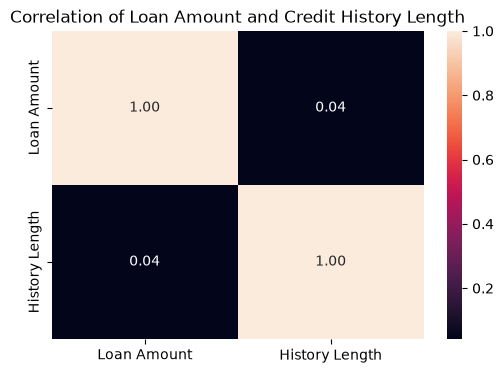

In [ ]:
amount_history_df = pd.read_csv('cleaned_credit_risk_dataset.csv')

# Rename columns
amount_history_df = amount_history_df.rename(
  columns={
    'Clean_loan_amnt':'Loan Amount',
    'Clean_cb_person_cred_hist_length':'History Length'
    })

# Store the person's r value
pearson = amount_history_df[['Loan Amount','History Length']].corr(method='pearson')

# Create the plot
fig, ax = plt.subplots(figsize=(6,4))

# Set title
ax.set_title('Correlation of Loan Amount and Credit History Length')

# Create the heatmap
heatmap = sb.heatmap(pearson, annot=True, fmt='.2f')


The heat map shows a very low correlation between the two variables. To further measure the relationship, the following line chart was used with the standard deviation as the errorbar:

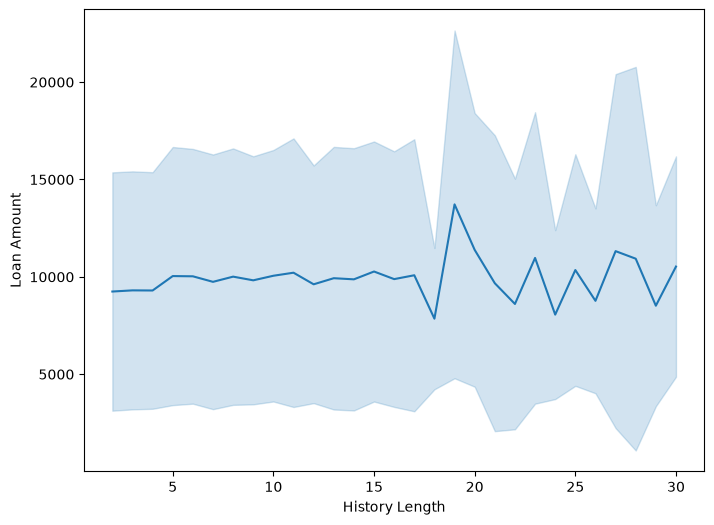

In [ ]:
# Create a new plot
fig, ax = plt.subplots(figsize=(8,6))

# Plot the line chart
log_regress = sb.lineplot(amount_history_df, x='History Length',y='Loan Amount', errorbar='sd')

The line chart shows that the loan amount did not show any signs of increment the longer the history length. It can be observed that the highest spike occured just before `20 years` but the confidence interval suggests sparse density instead of a trend. Therefore, the null hypothesis is supported and the alternative hypothesis cannot be supported.

*Ho*: The credit history does not affect the amount of money loaned.
*Ha*: The credit history does affect the amount of money loaned.
*Conclusion*: Based on the Pearson's r and line chart, there is not enough evidence to support the alternative hypothesis, therefore the null hypothesis is not rejected.